# Clonal-tree inference from DNA: bulk, single-cell, and phylogeography

A tumour's **clonal phylogeny** — which subclone descended from which — is what copy-number and
mutation callers ultimately want to reconstruct. iscc knows the **true genealogy** of every clone
(`genotypes_parents`), the ground truth no real dataset has, so we can *score* a reconstruction.

We reconstruct it three ways from the shared tumour:

* **bulk DNA-seq** sees one averaged variant-allele-frequency (VAF) spectrum — it separates a few
  frequency tiers but **mixes clones together**;
* **single-cell DNA-seq** reads each cell's mutations, so it resolves subclones a bulk VAF cannot;
* **phylogeography** — the ductal field is **multi-focal**: one founder colonises several glands through
  cross-gland (island) dispersal, so the section holds several *clonally related* foci. From
  `cell_gland` + the per-focus mutations we reconstruct the **inter-gland spread tree** (which gland
  seeded which) and confirm the shared-origin signature (every focus traces to one founder).

> One caveat this notebook does *not* chase: a multi-region **bulk** "sample tree" is not the clone
> tree — quantified in `validation/validate_multiregion_phylo.py` (and the ductal-field spread benchmark
> in `validation/validate_ductal_field.py`).

In [1]:
%matplotlib inline
import os, sys
sys.path.insert(0, os.path.abspath("."))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import base_sim as B
from iscc.data import scDNA, bulkDNA
from iscc.integrations import to_lineage_tree

## 1. Grow the tumour and read its true clonal structure

We grow the shared tumour and sample a few hundred malignant cells. Because the tumour is deeply
polyclonal, we summarise the genealogy into **K lineage clades** — groups of cells cut from the *true*
clone tree by their tree distance (`genotypes_parents` → pairwise lowest-common-ancestor distance).
These clades, and the tree relating them, are the answer key.

In [2]:
from sklearn.cluster import AgglomerativeClustering

t = B.grow_base_tumor()
cd = t.cell_data
types = B.cell_types(t)
idx = np.asarray(cd["cell_type"].index)
is_cancer = types == "cancer"
gid_all = cd["cell_type"].iloc[:, 0].astype(str).values

rng = np.random.default_rng(0)
sample_cells = list(rng.choice(idx[is_cancer], size=250, replace=False))
spos = np.array([np.where(idx == c)[0][0] for c in sample_cells])
gid_sample = gid_all[spos]

# true lineage distances (LCA on the genotype tree) among the sampled cells
lt = to_lineage_tree(t)
uniq = list(dict.fromkeys(gid_sample))
Du = lt.distance_matrix(ids=uniq)
gi = {g: i for i, g in enumerate(uniq)}
cell_gi = np.array([gi[g] for g in gid_sample])
Dlca = Du[np.ix_(cell_gi, cell_gi)]           # per-cell true tree distance

K = 6
clade = AgglomerativeClustering(n_clusters=K, metric="precomputed",
                                linkage="average").fit_predict(Du)
clade_cell = np.array([clade[cell_gi[i]] for i in range(len(sample_cells))])
reps = []
for k in range(K):
    gs = gid_sample[clade_cell == k]
    vals, cnts = np.unique(gs, return_counts=True); reps.append(vals[cnts.argmax()])
D_clade = lt.distance_matrix(ids=reps)         # true tree distances between clades
print(f"sampled {len(sample_cells)} malignant cells -> {K} true lineage clades "
      f"(sizes {[int((clade_cell==k).sum()) for k in range(K)]})")

sampled 250 malignant cells -> 6 true lineage clades (sizes [233, 12, 2, 1, 1, 1])


The clades sit in **coherent spatial patches** (left; lineage and space are correlated because
neighbours share ancestors), and the **true clade tree** (right, UPGMA on the true lineage distances)
is what both DNA modalities try to recover.

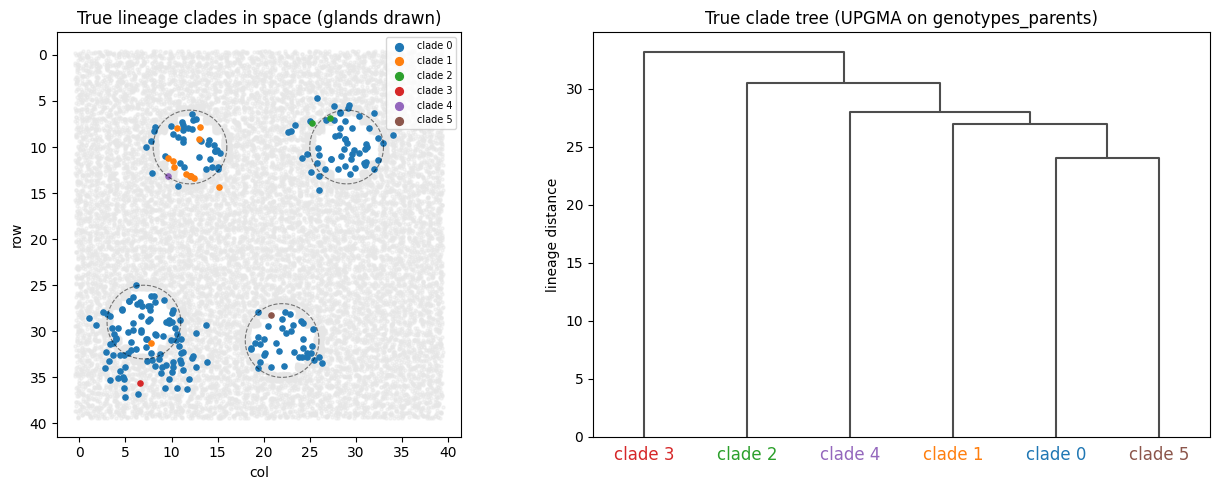

In [3]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

crd = cd["cell_crd"]
jit = np.random.default_rng(1)
jx = crd["col"].values + jit.uniform(-0.45, 0.45, len(crd))
jy = crd["row"].values + jit.uniform(-0.45, 0.45, len(crd))
cmap = plt.get_cmap("tab10")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(jx[~is_cancer], jy[~is_cancer], s=5, c="0.9", alpha=0.4)
for k in range(K):
    m = spos[clade_cell == k]
    axes[0].scatter(jx[m], jy[m], s=14, color=cmap(k), label=f"clade {k}")
B.draw_glands(axes[0], t)
axes[0].set_aspect("equal"); axes[0].invert_yaxis(); axes[0].legend(fontsize=7, markerscale=1.5)
axes[0].set_title("True lineage clades in space (glands drawn)")
axes[0].set_xlabel("col"); axes[0].set_ylabel("row")

Zt = linkage(squareform(D_clade, checks=False), method="average")
dn = dendrogram(Zt, ax=axes[1], labels=[f"clade {k}" for k in range(K)],
                link_color_func=lambda _: "0.3")
for lbl in axes[1].get_xmajorticklabels():
    lbl.set_color(cmap(int(lbl.get_text().split()[1])))
axes[1].set_title("True clade tree (UPGMA on genotypes_parents)")
axes[1].set_ylabel("lineage distance")
plt.tight_layout()

## 2. Single-cell DNA-seq recovers the genealogy

We run scDNA on the sampled cells and turn each cell's observed VAF into a mutation-presence profile.
The read on recovery is the **cophenetic correlation**: do the observed cell–cell mutation distances
track the **true tree distance** (the lowest-common-ancestor distance on `genotypes_parents`)? A
positive correlation means single cells carry real phylogenetic signal. We show it as a scatter, and as
a UPGMA tree of the cells with each leaf tick-coloured by its true clade.

scDNA: 600 informative sites | cophenetic correlation (observed distance vs true lineage distance) r = 0.69


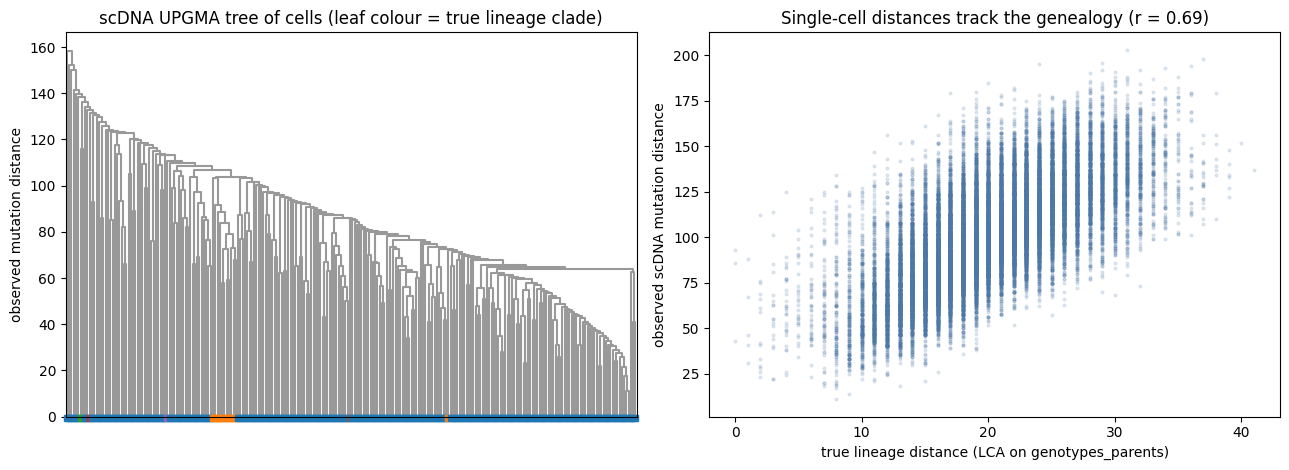

In [4]:
from scipy.stats import pearsonr

dna = scDNA(n_cells=len(sample_cells), breadth="wgs", seed=7, mu_depth=100, kappa=100).run(
    cd, cell_subset=sample_cells)
vaf = dna.vaf.reindex(sample_cells).values
present = (vaf > 0.1).astype(int)
info = present.std(0) > 0
Dobs = (present[:, info][:, None, :] != present[:, info][None, :, :]).sum(-1).astype(float)

iu = np.triu_indices(len(sample_cells), 1)
coph = pearsonr(Dlca[iu], Dobs[iu])[0]
print(f"scDNA: {int(info.sum())} informative sites | cophenetic correlation "
      f"(observed distance vs true lineage distance) r = {coph:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
Zo = linkage(squareform(Dobs, checks=False), method="average")
dn = dendrogram(Zo, ax=axes[0], no_labels=True, color_threshold=0, link_color_func=lambda _: "0.6")
for i, leaf in enumerate(dn["leaves"]):
    axes[0].plot(5 + 10 * i, -0.5, marker="s", ms=4, color=cmap(clade_cell[leaf]), clip_on=False)
axes[0].set_title("scDNA UPGMA tree of cells (leaf colour = true lineage clade)")
axes[0].set_ylabel("observed mutation distance"); axes[0].set_xticks([])

axes[1].scatter(Dlca[iu], Dobs[iu], s=4, alpha=0.15, color="#4c78a8")
axes[1].set_xlabel("true lineage distance (LCA on genotypes_parents)")
axes[1].set_ylabel("observed scDNA mutation distance")
axes[1].set_title(f"Single-cell distances track the genealogy (r = {coph:.2f})")
plt.tight_layout()

## 3. Bulk DNA-seq: fewer, coarser subclones

Bulk sequencing pools all the cells, so it sees one **VAF spectrum**. Clustering the mutated genes by
their bulk VAF resolves only a handful of **frequency tiers** — a coarse subclonal decomposition — far
fewer than the clades single cells resolve, and blind to which mutations co-occur in the same cell.

bulk resolves 6 VAF tiers (freqs [0.21, 0.15, 0.11, 0.08, 0.06, 0.04]) from one averaged spectrum; single-cell reads 250 individual profiles out of 8,517 living clones


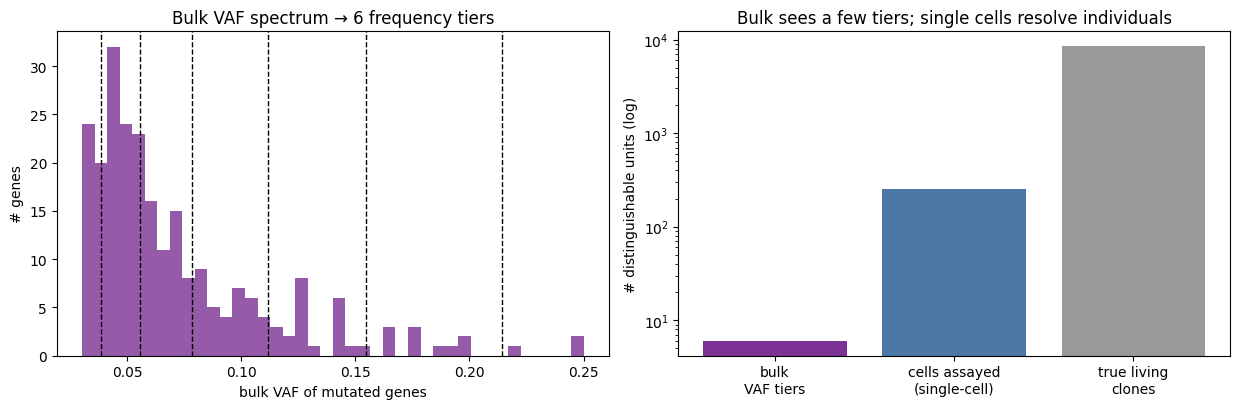

In [5]:
from sklearn.cluster import KMeans

bulk = bulkDNA(breadth="wgs", data_mode="counts").run(cd)
od = bulk.observed_data
mutated = od["true_alt_fraction"].values > 0.02
bvaf = od["vaf"].values[mutated]
bvaf = bvaf[bvaf > 0.03]

ks = range(1, 7)
inertias = [KMeans(n_clusters=k, n_init=5, random_state=0).fit(bvaf.reshape(-1, 1)).inertia_
            for k in ks]
# a simple elbow: last k with a >20% inertia drop
drops = [(inertias[i-1]-inertias[i])/inertias[i-1] for i in range(1, len(inertias))]
n_tiers = 1 + sum(1 for d in drops if d > 0.2)
km = KMeans(n_clusters=n_tiers, n_init=5, random_state=0).fit(bvaf.reshape(-1, 1))
centers = np.sort(km.cluster_centers_.ravel())[::-1]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
axes[0].hist(bvaf, bins=40, color="#7b3294", alpha=0.8)
for c in centers:
    axes[0].axvline(c, color="k", ls="--", lw=1)
axes[0].set_xlabel("bulk VAF of mutated genes"); axes[0].set_ylabel("# genes")
axes[0].set_title(f"Bulk VAF spectrum → {n_tiers} frequency tiers")

n_living = int(pd.Series(gid_all[is_cancer]).nunique())
axes[1].bar(["bulk\nVAF tiers", "cells assayed\n(single-cell)", "true living\nclones"],
            [n_tiers, len(sample_cells), n_living], color=["#7b3294", "#4c78a8", "0.6"])
axes[1].set_yscale("log"); axes[1].set_ylabel("# distinguishable units (log)")
axes[1].set_title("Bulk sees a few tiers; single cells resolve individuals")
plt.tight_layout()
print(f"bulk resolves {n_tiers} VAF tiers (freqs {np.round(centers,2).tolist()}) from one averaged "
      f"spectrum; single-cell reads {len(sample_cells)} individual profiles out of {n_living:,} living clones")

## 4. Phylogeography: the multi-focal foci are one clone spreading

The ductal field gives a second kind of tree the single-focus view cannot: a **spread tree** between
foci. One founder (in gland 0, ground truth) seeds other glands' lumens through cross-gland island
dispersal, so every focus is **clonally related** to the origin. From each focus's consensus mutation
profile we (a) confirm the whole lesion traces to **one** founder, (b) reconstruct the **inter-gland
spread tree** as a minimum spanning tree over between-focus genetic distance (rooted, for reference, at
the true founder gland), and (c) compare divergence: because the field colonises fast and early from a
near-clonal founder, the **foci consensuses stay close** (low between-focus divergence — a shared
truncal genome), and most of the diversity is **within** each grown focus. That similarity *is* the
clonal-relatedness signal: several foci, one clone. This is the multi-region phylogeography benchmark of
`validation/validate_ductal_field.py`, in a DCIS setting with a known answer.

phylogeography: 4 colonised foci | 100% of cancer clones trace to ONE founder (clonal)
divergence — between-focus 0.030 vs within-focus 0.170 SNV fraction (foci share the truncal mutations; the diversity is inside each grown focus)


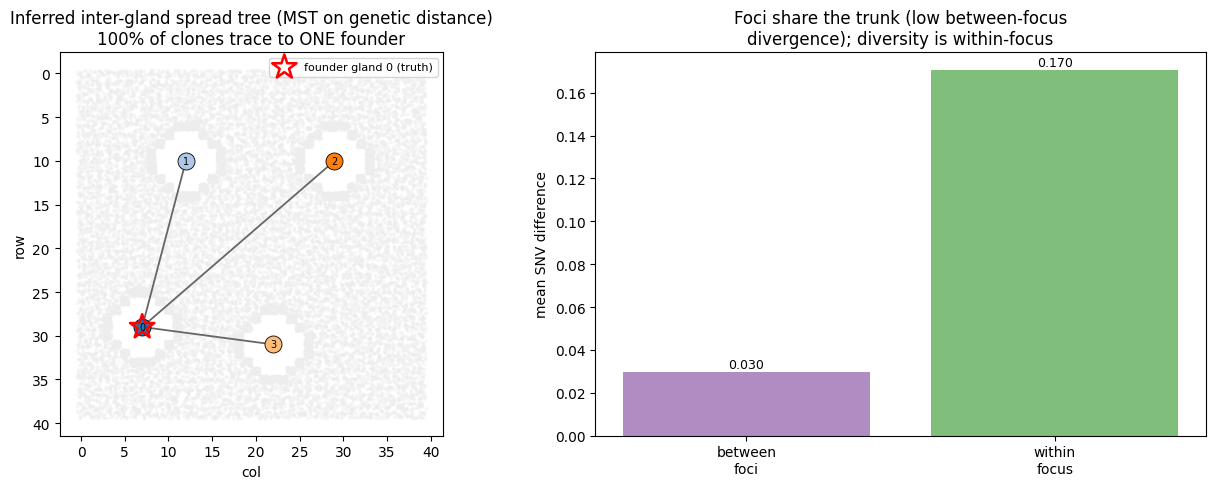

In [6]:
from scipy.sparse.csgraph import minimum_spanning_tree

gland = B.cell_gland(t)
snv = cd["cell_snv"].values > 0                        # binary mutation presence, all cells
colonised = sorted(g for g in set(gland[is_cancer].tolist()) if g >= 0)
consensus = {g: (snv[is_cancer & (gland == g)].mean(0) > 0.5) for g in colonised}   # per-focus profile

# (a) relatedness: does every cancer clone trace back to the single founder?
parents, founder = t.genotypes_parents, t.founder_id
def traces_to_founder(g, _seen=0):
    while g != founder and g in parents and _seen < 10**6:
        g = parents[g]; _seen += 1
    return g == founder
cancer_gids = [g for g in t.genotypes_counts if t._is_cancer(g)]
frac_related = float(np.mean([traces_to_founder(g) for g in cancer_gids]))

# (b) inferred spread tree: MST over between-focus genetic (Hamming) distance
G = colonised
D = np.array([[np.mean(consensus[a] != consensus[b]) for b in G] for a in G])
mst = minimum_spanning_tree(D).toarray(); mst = mst + mst.T

# (c) within- vs between-focus divergence
within = float(np.mean([np.mean(snv[is_cancer & (gland == g)] != consensus[g]) for g in G]))
btwn = [np.mean(consensus[G[i]] != consensus[G[j]]) for i in range(len(G)) for j in range(i + 1, len(G))]
between = float(np.mean(btwn)) if btwn else 0.0

centers = np.array(t.gland_centers)                    # (row, col) per gland
cmap20 = plt.get_cmap("tab20")
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(jx[~is_cancer], jy[~is_cancer], s=3, c="0.93", alpha=0.3)
for a in range(len(G)):
    for b in range(a + 1, len(G)):
        if mst[a, b] > 0:
            axes[0].plot([centers[G[a]][1], centers[G[b]][1]], [centers[G[a]][0], centers[G[b]][0]],
                         "-", color="0.4", lw=1.3, zorder=1)
for gi in G:
    r, c = centers[gi]
    axes[0].scatter([c], [r], s=150, color=cmap20(gi % 20), edgecolor="k", lw=0.6, zorder=2)
    axes[0].text(c, r, str(gi), ha="center", va="center", fontsize=7, zorder=3)
fr, fc = centers[0]
axes[0].scatter([fc], [fr], marker="*", s=340, facecolor="none", edgecolor="red", lw=1.8, zorder=4,
                label="founder gland 0 (truth)")
axes[0].set_aspect("equal"); axes[0].invert_yaxis(); axes[0].legend(fontsize=8, loc="upper right")
axes[0].set_title(f"Inferred inter-gland spread tree (MST on genetic distance)\n"
                  f"{frac_related*100:.0f}% of clones trace to ONE founder")
axes[0].set_xlabel("col"); axes[0].set_ylabel("row")

axes[1].bar(["between\nfoci", "within\nfocus"], [between, within], color=["#af8dc3", "#7fbf7b"])
axes[1].set_ylabel("mean SNV difference")
axes[1].set_title("Foci share the trunk (low between-focus\ndivergence); diversity is within-focus")
for i, v in enumerate([between, within]):
    axes[1].text(i, v + 0.002, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout()
print(f"phylogeography: {len(G)} colonised foci | {frac_related*100:.0f}% of cancer clones trace to ONE founder (clonal)")
print(f"divergence — between-focus {between:.3f} vs within-focus {within:.3f} SNV fraction "
      f"(foci share the truncal mutations; the diversity is inside each grown focus)")

## What this shows

* iscc supplies the **true clonal genealogy** (`genotypes_parents` → `iscc.integrations.to_lineage_tree`),
  so a DNA-based tree can be *scored*, not just drawn.
* **Single-cell DNA** recovers real phylogenetic signal: the observed mutation distances **track the
  true lineage distance** (positive cophenetic correlation) — above the bulk floor, even in this
  deeply polyclonal tumour where no clone dominates.
* **Bulk DNA** collapses the same tumour to a few **VAF tiers** — orders of magnitude coarser than the
  thousands of true clones, and unable to say which mutations share a cell.
* **Phylogeography** — the multi-focal foci are **one clone spreading**: (nearly) every cancer clone
  traces to a single founder, an inter-gland **spread tree** is recoverable from `cell_gland` + the
  per-focus mutations, and the foci **consensuses stay close** (low between-focus divergence — a shared
  truncal genome), with the diversity accumulating *within* each grown focus — a DCIS multi-region
  phylogeny with a known answer.
* The numbers are honest floors from lightweight distance methods (`scipy`), not tool results — the
  production phylogenetics (and the multi-region "sample tree ≠ clone tree" caveat) live in
  `validation/validate_multiregion_phylo.py` and `validation/validate_ductal_field.py`.

**Next / see also:**
[`base_simulation`](base_simulation.ipynb) · [`combining_scdna_scrna`](combining_scdna_scrna.ipynb)
(scDNA + scRNA) · [`cohort_mhn_recurrence`](cohort_mhn_recurrence.ipynb) (mutation order across a
cohort) · `validation/validate_multiregion_phylo.py` · `validation/validate_ductal_field.py`.